<a href="https://colab.research.google.com/github/RobiNormy/RobiNormy/blob/main/LEGO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
colors = pd.read_csv('colors.csv')
colors.head()
colors['name'].nunique()
colors.groupby('is_trans').count()

,id,name,rgb
is_trans,,,
f,107,107,107
t,28,28,28


### Understanding LEGO Themes vs. LEGO Sets
Walk into a LEGO store and you will see their products organised by theme. Their themes include Star Wars, Batman, Harry Potter and many more. <img src="https://i.imgur.com/akcwkSx.png">
A lego ** set ** is a particular box of LEGO or product. Therefore, a single theme typically has many different sets. <img src="https: //i. imgur. com/whBlolq. png">

In [43]:
sets = pd.read_csv('sets.csv')
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [44]:
sets.sort_values('year').head()

,set_num,name,year,theme_id,num_parts
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9534,700.2-1,Large Gift Set (ABB),1949,365,178


In [45]:
sets[sets['year'] == 1949]

,set_num,name,year,theme_id,num_parts
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9534,700.2-1,Large Gift Set (ABB),1949,365,178
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12


In [46]:
sets.sort_values('num_parts',ascending=False).head()

,set_num,name,year,theme_id,num_parts
15004,BIGBOX-1,The Ultimate Battle for Chima,2015,571,9987
11183,75192-1,UCS Millennium Falcon,2017,171,7541
10551,71043-1,Hogwarts Castle,2018,246,6020
295,10256-1,Taj Mahal,2017,673,5923
221,10189-1,Taj Mahal,2008,673,5922


In [47]:
import matplotlib.pyplot as plt
set_year = sets.groupby('year').count()
set_year['set_num'].head()
set_year['set_num'].tail()


,set_num
year,
2017,786
2018,816
2019,840
2020,674
2021,3


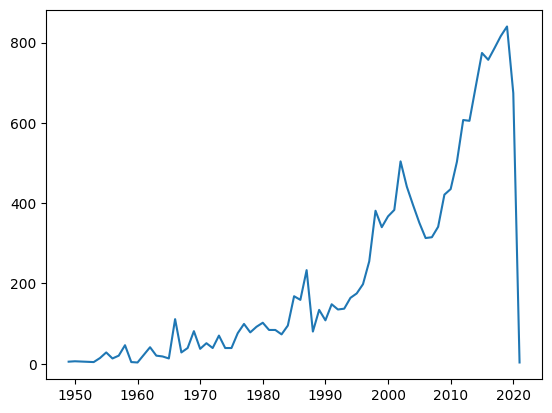

In [48]:
plt.plot(set_year.index,set_year.set_num)

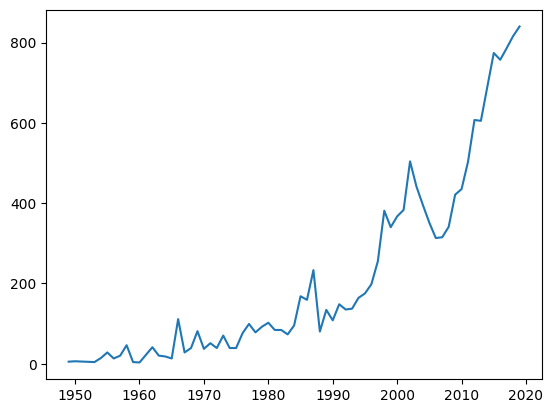

In [49]:
plt.plot(set_year.index[:-2],set_year.set_num[:-2])

In [50]:
theme_by_year = sets.groupby('year').agg({'theme_id':pd.Series.nunique})
theme_by_year.head()

,theme_id
year,
1949,2
1950,1
1953,2
1954,2
1955,4


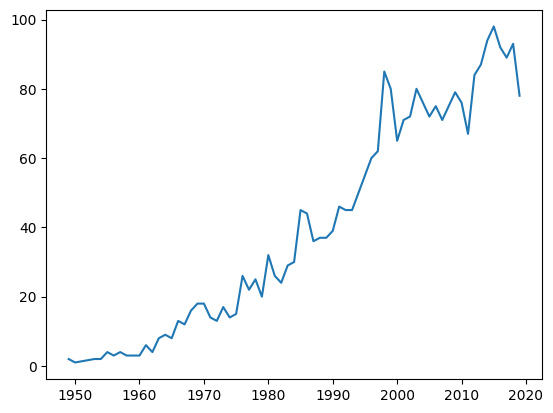

In [51]:
plt.plot(theme_by_year.index[:-2],theme_by_year.theme_id[:-2])

Text(0, 0.5, 'Number of Themes')

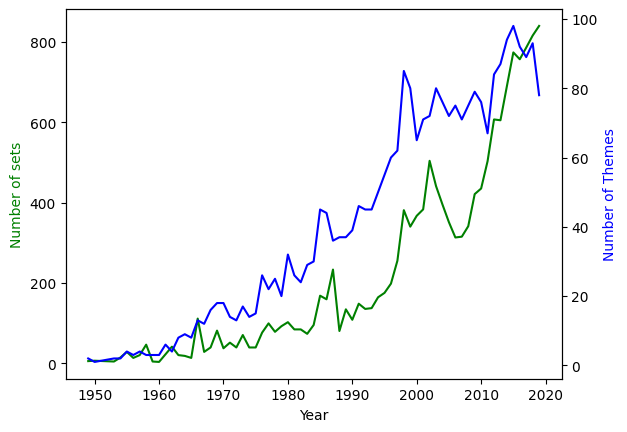

In [52]:
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.plot(set_year.index[:-2],set_year.theme_id[:-2],color = 'green')
ax2.plot(theme_by_year.index[:-2],theme_by_year.theme_id[:-2],'b')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of sets',color='green')
ax2.set_ylabel('Number of Themes',color = 'blue')

In [53]:
parts_per_set = sets.groupby('year').agg({'num_parts':'mean'})
parts_per_set.head()
parts_per_set.tail()



,num_parts
year,
2017,221.840967
2018,213.618873
2019,207.510714
2020,259.732938
2021,0.000000


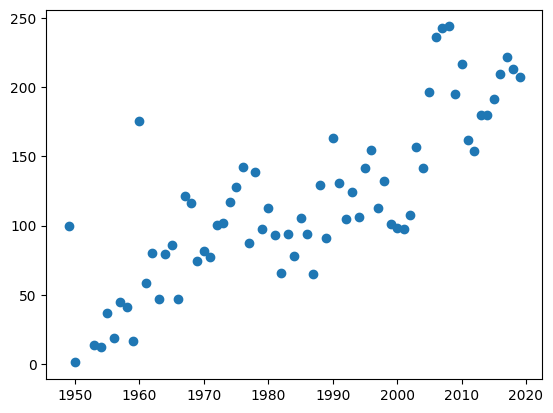

In [54]:
plt.scatter(parts_per_set.index[:-2],parts_per_set.num_parts[:-2])

<img src="https://i.imgur.com/Sg4lcjx.png">


In [55]:
themes = pd.read_csv('themes.csv')
themes.head()

,id,name,parent_id
0,1,Technic,NaN
1,2,Arctic Technic,1.0
2,3,Competition,1.0
3,4,Expert Builder,1.0
4,5,Model,1.0


In [56]:
themes[themes.name == 'Star Wars']

,id,name,parent_id
17,18,Star Wars,1.0
150,158,Star Wars,NaN
174,209,Star Wars,207.0
211,261,Star Wars,258.0


In [58]:
sets[sets.theme_id == 18]

,set_num,name,year,theme_id,num_parts
8786,65081-1,R2-D2 / C-3PO Droid Collectors Set,2002,18,1
12051,8000-1,Pit Droid,2000,18,223
12058,8001-1,Battle Droid,2000,18,336
12066,8002-1,Destroyer Droid,2000,18,567
12071,8007-1,C-3PO,2001,18,339
12072,8008-1,Stormtrooper,2001,18,360
12073,8009-1,R2-D2,2002,18,239
12074,8010-1,Darth Vader,2002,18,388
12081,8011-1,Jango Fett,2002,18,425
12083,8012-1,Super Battle Droid,2002,18,378


In [59]:
set_theme_count = sets['theme_id'].value_counts()
set_theme_count.head()

,count
theme_id,
158,753
501,656
494,398
435,356
503,329


In [61]:
set_theme_count = pd.DataFrame({'id':set_theme_count.index,'set_count':set_theme_count.values})
set_theme_count.head()


ValueError: Per-column arrays must each be 1-dimensional

In [62]:
merged = pd.merge(set_theme_count,themes,on='id')
merged[:3]

,id,set_count,name,parent_id
0,158,753,Star Wars,NaN
1,501,656,Gear,NaN
2,494,398,Friends,NaN


<BarContainer object of 10 artists>

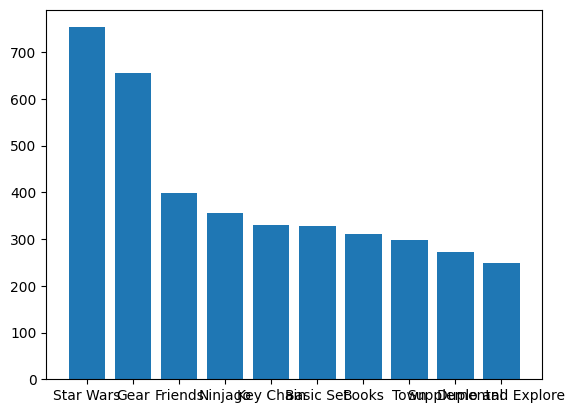

In [65]:
plt.bar(merged.name[:10],merged.set_count[:10])


<BarContainer object of 10 artists>

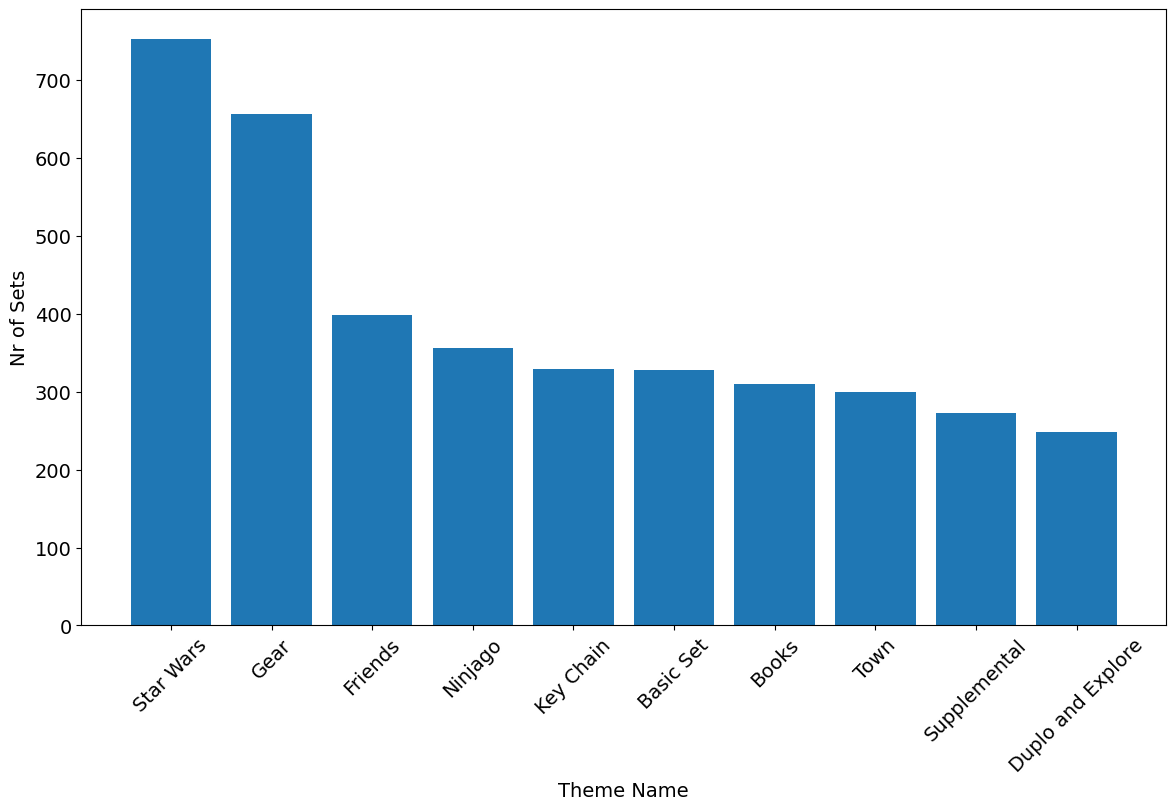

In [67]:
plt.figure(figsize=(14,8))
plt.xticks(fontsize = 14, rotation = 45)
plt.yticks(fontsize = 14 )
plt.ylabel('Nr of Sets',fontsize = 14)
plt.xlabel('Theme Name',fontsize = 14)
plt.bar(merged.name[:10],merged.set_count[:10])